In [207]:
# Importing pandas into our workspace
import pandas as pd
from matplotlib import pyplot as plt


In [208]:
# Reading our orders dataframe, formatting it and analyzing it

orders_df = pd.read_csv('../InstaCart-Data-Analysis/data/instacart_orders.csv', sep=";")
# print(orders_df.head(10))
print(orders_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None


Our orders dataset has 478,967 rows and 5 columns. We see that our days_since_prior_order has 28,819 Null values. We could have more missing data however that we need to check for. All rows are integers besides the day_since_prior_order. This makes sense since we can have 31.5 days for example. 

In [209]:
# Reading our products dataframe, formatting it and analyzing it
products_df = pd.read_csv('../InstaCart-Data-Analysis/data/products.csv', sep=";")
# print(products_df.head(10))
print(products_df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


Our products dataset has 49,694 rows. Our product_name is the only row that has 1,258 Null values. All rows are integers besides our product_name which is a string or object. 

In [210]:
# Reading our departments dataframe, formatting it and analyzing it
departments_df = pd.read_csv('../InstaCart-Data-Analysis/data/departments.csv', sep=";")
# print(departments_df.head(10))
print(departments_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes
None


We have a very small dataset here for our departments dataframe. 21 rows, no missing values. Our department_id is a integer and our department is a string or object. 

In [211]:
# Reading our aisles dataframe, formatting it and analyzing it
aisles_df = pd.read_csv('../InstaCart-Data-Analysis/data/aisles.csv', sep=";")
# print(aisles_df.head(10))
aisles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


Another small dataset for our aisles data frame. 134 rows. Two columns, our aisle_id which is an integer and our aisle which is an object. 

In [212]:
# Reading our order products dataframe, formatting it and analyzing it
order_products_df = pd.read_csv('../InstaCart-Data-Analysis/data/order_products.csv', sep=";")
# print(order_products_df.sample(20))
print(order_products_df.info(show_counts=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


Our order products dataset is a very large dataset. We have 4,545,007 rows of data with 4 columns. All of our columns are integers besides our add_to_cart_order which is a float. However based on what we know about this column a float might not be best. This column represents the order in which items were placed in the cart. That column also seems to have 971 Null values. 

## Find and remove duplicate values (and describe why you make your choices)

### `orders` data frame

In [213]:
# Check for duplicated orders
duplicated_orders = orders_df.duplicated()
print(f"Our duplicated sum is {duplicated_orders.sum()}")


Our duplicated sum is 15


Here I am created a variable called duplicated_orders and I am then calling duplicated() on our dataframe. I am then printing the sum. This will tell the total amount of dupliacted rows.

In [214]:
# Check for all orders placed Wednesday at 2:00 AM

# order_hour_of_day should be 2 and order_dow needs to be 3
orders_placed_wednesday = orders_df[(orders_df['order_dow'] == 3) & (orders_df['order_hour_of_day'] == 2)]
print(orders_placed_wednesday)


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

Creating a variable to store orders placed on the third weekday (Wednesday) and at 2am. We have 121 rows or orders that we placed on a wednesday at 2am.

In [215]:
# Remove duplicate orders
orders_df.drop_duplicates(keep='first', inplace=True)


Removing our duplicated rows keeping the first occurrence and using the inplace param to ensure that the change is made to the originak dataframe.

In [216]:
# Double check for duplicate rows
print(orders_df.duplicated(keep=False).sum())


0


Double checking that we no longer have no remaining duplicated rows in our orders dataframe.

In [217]:
# Double check for duplicate order IDs only
print(orders_df['order_id'].duplicated().sum())


0


Ensuring we do not have any duplicated values in the order_id column. This is essential because our order_id should always be unique.

### `products` data frame

In [218]:
# Check for fully duplicate rows
duplicated_products_rows = products_df.duplicated().sum()
print(duplicated_products_rows)


0


Checking if our dataframe has fully duplicated rows.

In [219]:
# Check for just duplicate product IDs
duplicated_product_ids = products_df['product_id'].duplicated().sum()
print(duplicated_product_ids)


0


Checking if the column of products_id in our dataframe has duplicates.

In [220]:
# Check for just duplicate product names (convert names to lowercase to compare better)
products_df['product_name'] = products_df['product_name'].str.lower()
duplicated_products = products_df['product_name'].duplicated().sum()
print(duplicated_products)


1361


Checking for duplicate product names.

In [221]:
# Check for duplicate product names that aren't missing
duplicated_products_not_missing = products_df['product_name'].dropna().duplicated().sum()
print(duplicated_products_not_missing)


104


Checking for duplicate product names but excluding values that are missing.

### `departments` data frame

In [222]:
print(departments_df.duplicated())

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
dtype: bool


Checking for duplicate values in our departments dataframe. With this being such a small dataset we can just call duplicated() to see if we have any duplicates. 

### `aisles` data frame

In [223]:
print(aisles_df.duplicated().sum())

0


Ensuring we have no duplicated values in our aisles dataframe.

### `order_products` data frame

In [224]:
# Check for fullly duplicate rows
duplicated_order_products = order_products_df.duplicated().sum()
print(duplicated_order_products)


0


Checking for fully duplicated rows.

In [225]:
# Double check for any other tricky duplicates
print(order_products_df.dropna().duplicated().sum())


0


Checking for duplicates after dropping NA values. 

## Find and remove missing values


### `products` data frame

In [226]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


Calling info() on our dataframe to determine where and how much missing data we have. In this case it seems that we only have missing values in our product_name column.

In [227]:
# Are all of the missing product names associated with aisle ID 100?
missing_products_names = products_df[products_df['product_name'].isna()]
print(missing_products_names['aisle_id'].unique())

[100]


Creating a new dataframe that checks for all of the NAN values in our product_names column. Then calling unique on the aisle_id to confirm that the only value is 100 meaning all missing values are from aise_id of 100.

In [228]:
# Are all of the missing product names associated with department ID 21?
missing_products_names = products_df[products_df["product_name"].isna()]
print(missing_products_names['department_id'].unique())


[21]


Creating a new dataframe that checks for all of the NAN values in our product_names column. Then calling unique on the department_id to confirm that the only value is 21 meaning all missing values are from department_id of 21.

In [229]:
# What is this ailse and department?
print(aisles_df.loc[aisles_df['aisle_id'] == 101, 'aisle'])
print(departments_df)
print(departments_df.loc[departments_df['department_id'] == 21, 'department'])

100    air fresheners candles
Name: aisle, dtype: object
    department_id       department
0               1           frozen
1               2            other
2               3           bakery
3               4          produce
4               5          alcohol
5               6    international
6               7        beverages
7               8             pets
8               9  dry goods pasta
9              10             bulk
10             11    personal care
11             12     meat seafood
12             13           pantry
13             14        breakfast
14             15     canned goods
15             16       dairy eggs
16             17        household
17             18           babies
18             19           snacks
19             20             deli
20             21          missing
20    missing
Name: department, dtype: object


Determing which aisle is 100 and which department is 21. This tells us which aisle and department our missing values are coming from.

In [230]:
# Fill missing product names with 'Unknown'
products_df['product_name'].fillna(value='Unknown', inplace=True)
print(products_df.isna().sum())
print()
print()
print((products_df['product_name'] == "Unknown").sum())


product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64


1258


/var/folders/2s/6s11c01n27g08gwkl3rs_2dc0000gn/T/ipykernel_6569/1628327055.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_name'].fillna(value='Unknown', inplace=True)


Filling in all of our missing values with "Unknown" and then checking that we have no missing values and that they were replaced with "Unknown".

### `orders` data frame

In [231]:
print(orders_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 478952 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478952 non-null  int64  
 1   user_id                 478952 non-null  int64  
 2   order_number            478952 non-null  int64  
 3   order_dow               478952 non-null  int64  
 4   order_hour_of_day       478952 non-null  int64  
 5   days_since_prior_order  450135 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 25.6 MB
None


In [232]:
# Are there any missing values where it's not a customer's first order?
missing_non_first_orders = orders_df[(orders_df['order_number'] > 1) & (orders_df['days_since_prior_order'].isna())]
print(missing_non_first_orders.shape[0])

0


Using a conditional to determine if there are any missing values where its NOT the customers first order. 

### `order_products` data frame

In [233]:
print(order_products_df.info(show_counts=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


In [234]:
# What are the min and max values in this column?
print(order_products_df['add_to_cart_order'].min())
print(order_products_df['add_to_cart_order'].max())

1.0
64.0


Getting the min and max values of our add_to_cart_order column.

In [235]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
order_id_with_missing_cart_order = order_products_df.loc[order_products_df['add_to_cart_order'].isna(), 'order_id']
print(order_id_with_missing_cart_order.head())

737      2449164
9926     1968313
14394    2926893
16418    1717990
30114    1959075
Name: order_id, dtype: int64


Extracting all of our rows where the add_to_cart_order has missing values and getting only the order_id column from those extracted rows. The left number is the index and the right number is the order_id.

In [236]:
# Do all orders with missing values have more than 64 products?
missing_cart_orders = order_products_df[order_products_df['add_to_cart_order'].isna()]
order_counts = missing_non_first_orders.groupby('order_id').size()

print((order_counts > 64).sum())


0


Grouping our data and checking if all of the orders with missing values have more than 64 products.

In [237]:
# Replace missing values with 999 and convert column to integer type
order_products_df['add_to_cart_order'].fillna(value=999, inplace=True)
order_products_df['add_to_cart_order'] = order_products_df['add_to_cart_order'].astype(int)
order_products_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB


/var/folders/2s/6s11c01n27g08gwkl3rs_2dc0000gn/T/ipykernel_6569/1870382193.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  order_products_df['add_to_cart_order'].fillna(value=999, inplace=True)


Filling in all of our missing values with 999 and converting the column to and int type.

# [A] Easy (must complete all to pass)

### [A1] Verify that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6)

In [238]:
print(orders_df['order_dow'].min())
print(orders_df['order_dow'].max())

0
6


Getting the Min and Max of the order_dow column. 0 in this case reprensets the first day of the week and 6 represents the last day of the week. Our order_dow column is sensible data.

In [239]:
print(orders_df['order_hour_of_day'].min())
print(orders_df['order_hour_of_day'].max())

0
23


Again, getting the Min and Max of the order_hour_of_day column. 0 in this case reprensets the first hour of the day and 23 represents the last hour of the day. Our order_hour_of_day column is sensible data.

### [A2] What time of day do people shop for groceries?

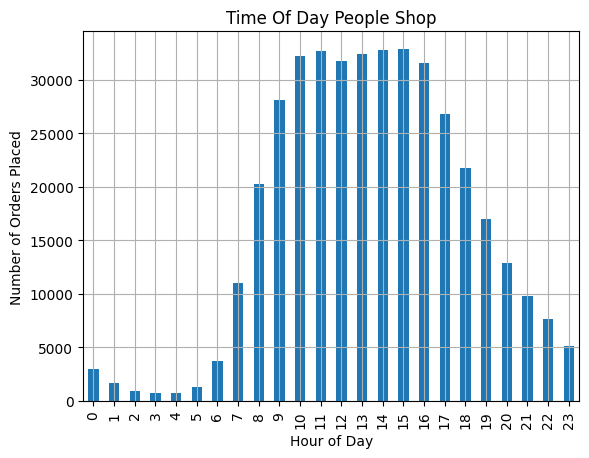

In [240]:

orders_hour = orders_df.groupby('order_hour_of_day')['user_id'].nunique()
orders_hour.plot(title="Time Of Day People Shop", kind='bar', xlabel="Hour of Day", ylabel="Number of Orders Placed", grid=True)

plt.show()


We first needed to determine the unique users. To do this we called groupby on our DF and grouped our order_hour_of_day by the user_id. However we needed unqiue users, so we use the nunique method to get the number of unique users for each hour. We then created a bar graph to show us the number of orders placed during each hour of the day. We can see that 10am - 4pm is the most common time to place orders, and 1am - 5am is the least common time.

### [A3] What day of the week do people shop for groceries?

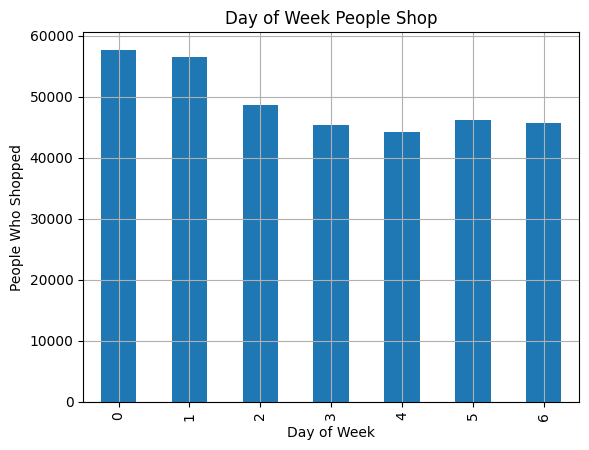

In [241]:
orders_dow = orders_df.groupby('order_dow')['user_id'].nunique()

orders_dow.plot(kind='bar', grid=True, title="Day of Week People Shop", xlabel='Day of Week', ylabel='People Who Shopped')
plt.show()

To determine the number of people who shop on specific weekdays, we created a bar graph. The graph shows that the most common days to shop would be day 0 and day 1 of the week. In others the beginning of the week. We then see the least amount of people shop in the middle of the week. 

### [A4] How long do people wait until placing another order?

In [242]:
orders_df.info()
print(orders_df['days_since_prior_order'].min())
print(orders_df['days_since_prior_order'].max())

<class 'pandas.core.frame.DataFrame'>
Index: 478952 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478952 non-null  int64  
 1   user_id                 478952 non-null  int64  
 2   order_number            478952 non-null  int64  
 3   order_dow               478952 non-null  int64  
 4   order_hour_of_day       478952 non-null  int64  
 5   days_since_prior_order  450135 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 25.6 MB
0.0
30.0


Checking the min and max of our days_since_prior_order column. The range seems to be only 30 days that we keep track of. Additionally, we are only keeping track of the day so if a person places an order the same day, thats all we know. We dont know how many hours they waited. 

<Axes: title={'center': 'Days Since Previous Order'}, xlabel='Days Since Last Order', ylabel='Orders Placed'>

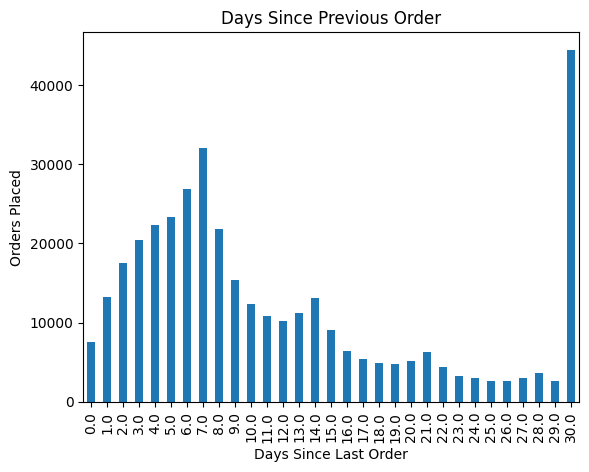

In [243]:
days_since_last_order = orders_df.groupby('days_since_prior_order')['user_id'].nunique()
days_since_last_order.plot(title='Days Since Previous Order', xlabel='Days Since Last Order', ylabel='Orders Placed', kind='bar')

Our plot shows that most people wait more than 30 days to place their next order while the second most common time to wait is only 7 days between orders. Our ability to analyze this metric in depth in quite limited with the data we are given.

# [B] Medium (must complete all to pass)

### [B1] Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the histograms for both days and describe the differences that you see.

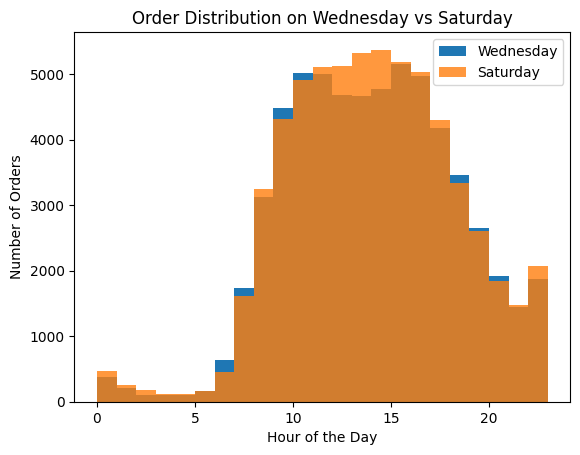

In [283]:

orders_on_wed = orders_df[orders_df['order_dow'] == 3]['order_hour_of_day'].plot(kind='hist', bins=23, label="Wednesday")
orders_on_sat = orders_df[orders_df['order_dow'] == 6]['order_hour_of_day'].plot(kind='hist', bins=23, alpha=0.8, label="Saturday")
plt.legend()
plt.xlabel('Hour of the Day')
plt.ylabel("Number of Orders")
plt.title('Order Distribution on Wednesday vs Saturday')
plt.show()



The plot abovd tells us that the shopping distribution for both Saturday and Wednesday is quite common however the main difference is that shopping is more frequent on Saturday. 

### [B2] What's the distribution for the number of orders per customer?

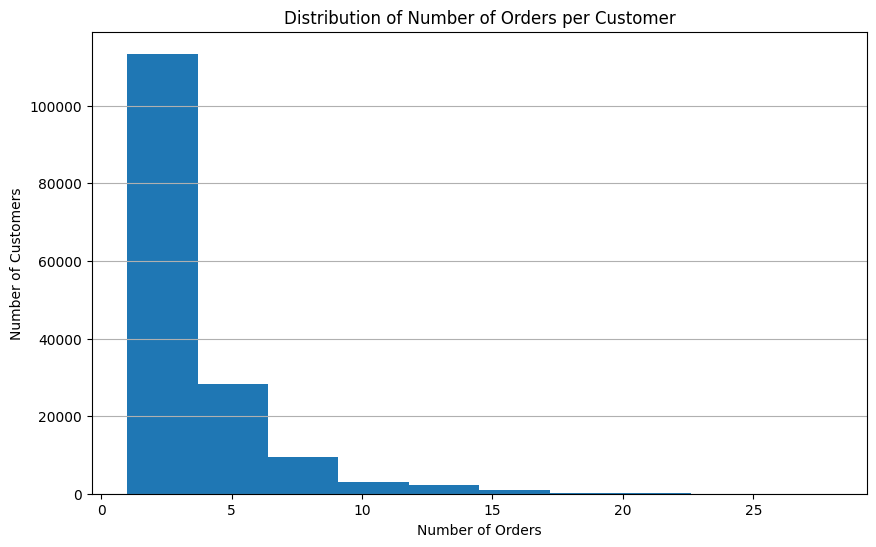

In [303]:

orders_placed  = orders_df.groupby('user_id')['order_number'].count()

plt.figure(figsize=(10, 6))
plt.hist(orders_placed, bins=10)
plt.title('Distribution of Number of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.grid(axis='y')
plt.show()

The plot above shows a histogram of the number of orders that customers generally place. Over 100,000 customers have placed less than 5 orders. 

### [B3] What are the top 20 popular products (display their id and name)?

In [ ]:
product_counts = order_products_df['product_id'].value_counts().reset_index()
# This here is renmaing our columns
product_counts.columns = ['product_id', 'order_count']
top_products = product_counts.merge(products_df, on='product_id')[['product_id', 'product_name', 'order_count']]
print(top_products.head(20))

    product_id              product_name  order_count
0        24852                    banana        66050
1        13176    bag of organic bananas        53297
2        21137      organic strawberries        37039
3        21903      organic baby spinach        33971
4        47209      organic hass avocado        29773
5        47766           organic avocado        24689
6        47626               large lemon        21495
7        16797              strawberries        20018
8        26209                     limes        19690
9        27845        organic whole milk        19600
10       27966       organic raspberries        19197
11       22935      organic yellow onion        15898
12       24964            organic garlic        15292
13       45007          organic zucchini        14584
14       39275       organic blueberries        13879
15       49683            cucumber kirby        13675
16       28204        organic fuji apple        12544
17        5876             o

# [C] Hard (must complete at least two to pass)

### [C1] How many items do people typically buy in one order? What does the distribution look like?

### [C2] What are the top 20 items that are reordered most frequently (display their names and product IDs)?

### [C3] For each product, what proportion of its orders are reorders?

### [C4] For each customer, what proportion of their products ordered are reorders?

### [C5] What are the top 20 items that people put in their carts first? 